In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/churn.csv")

# Display first few rows
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Matplotlib is building the font cache; this may take a moment.


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# Check data types and missing values
print(df.info())
print("\n" + "="*50)
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Summary statistics
print(df.describe())
print("\n" + "="*50)
print("\nTarget variable distribution:")
print(df['Churn'].value_counts())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
# Convert TotalCharges to numeric (some values might be strings with spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were created
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with 0 (these are likely new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("✓ TotalCharges cleaned successfully")

Missing values in TotalCharges after conversion: 0
✓ TotalCharges cleaned successfully


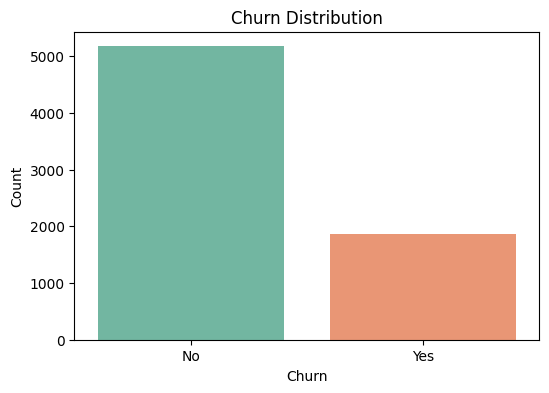

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
# Plot churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

# Print percentages
print(df['Churn'].value_counts(normalize=True) * 100)

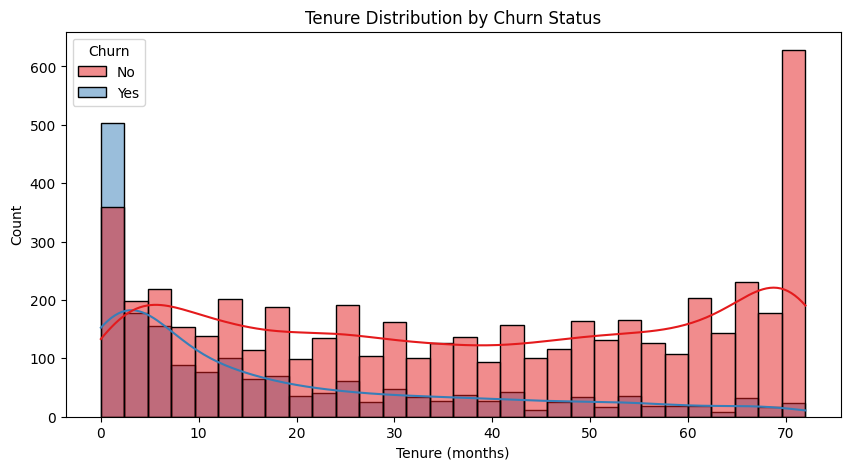

In [8]:
# Tenure distribution by churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.show()

C:\Users\Hemanth\AppData\Local\Temp\ipykernel_22716\180701037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


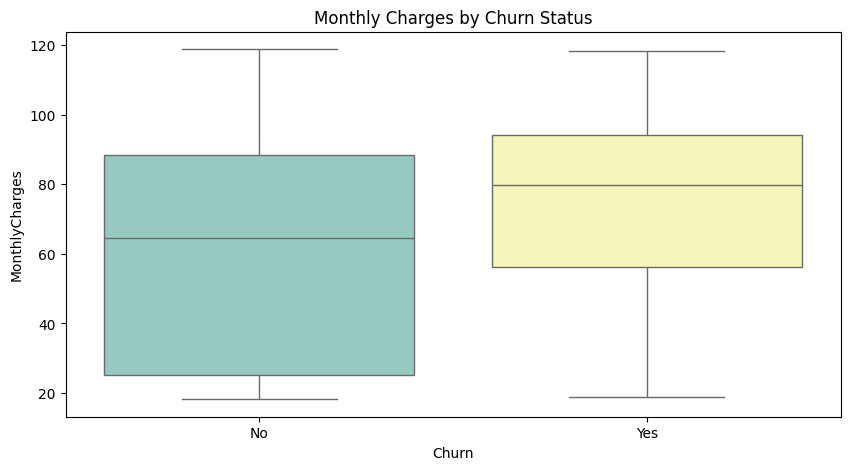

In [9]:
# Monthly charges by churn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title('Monthly Charges by Churn Status')
plt.show()

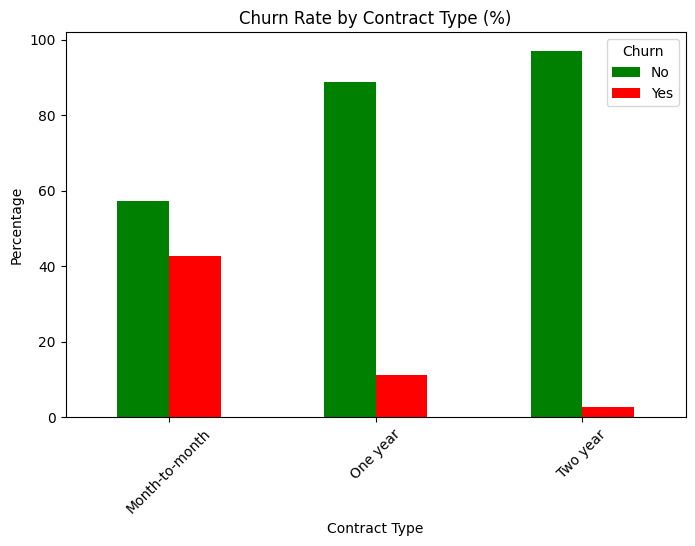


Churn rate by contract type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [10]:
# Contract type impact on churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False, figsize=(8, 5), color=['green', 'red'])
plt.title('Churn Rate by Contract Type (%)')
plt.ylabel('Percentage')
plt.xlabel('Contract Type')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

print("\nChurn rate by contract type:")
print(contract_churn)